# Ticket Data Analysis

Loads and explores the ~20k work item (Incident/Request/etc.) records from a JSON file.

Set `DATA_PATH` below to point at your JSON file.

In [2]:
import json
from pathlib import Path

import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

In [4]:
# Path to the JSON file with the work item records (adjust as needed)
DATA_PATH = Path("jira_first_20000_requested_fields_synthetic.json")

with open(DATA_PATH, "r", encoding="utf-8") as f:
    records = json.load(f)

print(f"Loaded {len(records):,} records")
records[0]

Loaded 20,000 records


{'Work type': 'Service Request',
 'Summary': 'New license requested for Tax Reporting',
 'Description': 'A new user requires a license for Tax Reporting to support an operational activity. The request includes the relevant user details and justification and needs validation before the entitlement is assigned.',
 'Affected Business or IT Services': ['Tax Reporting'],
 'Business Entity': ['Nordics'],
 'Service Team(s)': ['Tax & Reporting'],
 'Reporter': 'luca.rinaldi@intcom.com',
 'Assignee': 'oliver.varga@intcom.com',
 'Priority': 'low',
 'Urgency': 'low',
 'Impact': 'low',
 'Created date': '2026-03-03 19:36',
 'Status': 'done',
 'Resolution': 'done',
 'Resolution date': '2026-03-16 11:51',
 'All Comments': ['nina.baker@intcom.com: Initial triage assigned to Tax & Reporting and reviewed against the service catalogue.',
  'peter.kuznetsov@intcom.com: We validated the issue against Tax Reporting and checked whether it matched the expected operating conditions.',
  'yasmine.fox@intcom.com:

## Build the DataFrame

List-valued fields (`Affected Business or IT Services`, `Business Entity`, `Service Team(s)`, `All Comments`) are kept as-is; dates are parsed.

In [5]:
df = pd.DataFrame(records)

date_cols = ["Created date", "Resolution date"]
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

df["Comment count"] = df["All Comments"].apply(lambda x: len(x) if isinstance(x, list) else 0)

print(df.shape)
df.head()

(20000, 17)


,Work type,Summary,Description,Affected Business or IT Services,Business Entity,Service Team(s),Reporter,Assignee,Priority,Urgency,Impact,Created date,Status,Resolution,Resolution date,All Comments,Comment count
0,Service Request,New license requested for Tax Reporting,A new user requires a license for Tax Reportin...,[Tax Reporting],[Nordics],[Tax & Reporting],luca.rinaldi@intcom.com,oliver.varga@intcom.com,low,low,low,2026-03-03 19:36:00,done,done,2026-03-16 11:51:00,[nina.baker@intcom.com: Initial triage assigne...,3
1,Service Request,New license requested for Outlook & Email,A new user requires a license for Outlook & Em...,[Outlook & Email],[Switzerland],[Enterprise Applications],maia.berg@intcom.com,jack.martin@intcom.com,low,medium,lowest,2026-06-07 07:38:00,done,cannot reproduce,2026-06-09 13:30:00,[louis.belov@intcom.com: Initial triage assign...,3
2,Service Request,Incorrect incident title for service request i...,The submitted title suggests an incident affec...,[Portfolio Accounting],[Switzerland],[Investment Operations],info@extcom_19.com,tania.gupta@intcom.com,lowest,low,medium,2026-06-23 14:00:00,done,clarification,2026-06-28 09:07:00,[marta.marchand@intcom.com: Initial triage ass...,3
3,Service Request,New license requested for Trading Platform,A new user requires a license for Trading Plat...,[Trading Platform],[Germany],[Investment Operations],carlos.ortiz@intcom.com,nora.leclerc@intcom.com,lowest,lowest,low,2026-01-23 06:26:00,done,cannot reproduce,2026-02-05 00:13:00,[ursula.klassen@intcom.com: Initial triage ass...,4
4,Service Request,Access requested for SimCorp Dimension,A user needs access to SimCorp Dimension to co...,[SimCorp Dimension],[Germany],[Enterprise Applications],celine.novak@intcom.com,xena.schmidt@intcom.com,low,lowest,medium,2026-07-08 11:54:00,done,clarification,2026-07-15 22:33:00,[olga.dupont@intcom.com: Initial triage assign...,4


## Quick overview

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Work type                         20000 non-null  str           
 1   Summary                           20000 non-null  str           
 2   Description                       20000 non-null  str           
 3   Affected Business or IT Services  20000 non-null  object        
 4   Business Entity                   20000 non-null  object        
 5   Service Team(s)                   20000 non-null  object        
 6   Reporter                          20000 non-null  str           
 7   Assignee                          20000 non-null  str           
 8   Priority                          20000 non-null  str           
 9   Urgency                           20000 non-null  str           
 10  Impact                            20000 non-null  str    

In [7]:
# Missing values per column
df.isna().sum().sort_values(ascending=False)

Resolution                          3031
Resolution date                     3031
Work type                              0
Summary                                0
Description                            0
Service Team(s)                        0
Reporter                               0
Affected Business or IT Services       0
Business Entity                        0
Priority                               0
Assignee                               0
Urgency                                0
Impact                                 0
Status                                 0
Created date                           0
All Comments                           0
Comment count                          0
dtype: int64

In [21]:
# Value counts for the key categorical fields
for col in ["Work type", "Priority", "Urgency", "Impact", "Status","Resolution","Summary","Description","Assignee"]:
    if col in df.columns:
        print(f"\n{col}:")
        print(df[col].value_counts(dropna=False))


Work type:
Work type
Incident           16000
Service Request     4000
Name: count, dtype: int64

Priority:
Priority
lowest     10037
low         6070
medium      1880
high        1629
highest      384
Name: count, dtype: int64

Urgency:
Urgency
lowest     10016
low         5979
medium      2008
high        1618
highest      379
Name: count, dtype: int64

Impact:
Impact
lowest     10064
low         5962
medium      1962
high        1636
highest      376
Name: count, dtype: int64

Status:
Status
done           16969
in progress     2064
open             967
Name: count, dtype: int64

Resolution:
Resolution
cannot reproduce    4322
clarification       4243
done                4236
cancelled           4168
NaN                 3031
Name: count, dtype: int64

Summary:
Summary
External email warning received for Emailed Support Tickets              4212
Email notification received for Emailed Support Tickets                  1211
Automated alert triggered for SimCorp Dimension              

## Clustering over all fields

Groups the tickets into **themes** using every field of the export, not just the text:

| Block | Fields | Encoding |
|---|---|---|
| Text | Summary + Description | TF-IDF (1–2-grams) → SVD |
| Comments | All Comments (author prefix removed) | TF-IDF → SVD |
| Categorical | Work type, Service, Team, Entity, Assignee, Reporter, Status, Resolution | one-hot (rare values folded) |
| Ordinal | Priority, Urgency, Impact | lowest…highest → 0…4, scaled |
| Numeric | resolution time (log), unresolved flag, comment count, created hour, weekday | scaled |

Each block is normalised to the same average size and then weighted (`WEIGHTS`), so a 20-column one-hot block cannot drown a 5-column numeric block by accident.

Two things about this export shape the setup:

- **The text is template-based.** There are only 173 distinct descriptions, and each one has the service name filled in. The service and team names are masked in the text. Without that, the text block would just repeat the Service field, and the clusters would follow the scenario (alert, access request, …) less well.
- **Priority / Urgency / Impact are random** (ADR-0001). They are included because the task is "all fields", but with a token weight. The field-profile heatmap below shows that they don't separate any theme.

Requires `scikit-learn` and `matplotlib` (`pip install scikit-learn matplotlib`).

In [9]:
import re
import textwrap

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEED = 42

# Chart tokens: one accent hue for single-series charts, a one-hue blue ramp for magnitude,
# recessive grey chrome. Themes are never told apart by colour alone (small multiples + labels).
INK, INK_2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
ACCENT, ACCENT_2, CONTEXT = "#2a78d6", "#eb6834", "#d9d8d2"
BLUES = LinearSegmentedColormap.from_list(
    "blues", ["#f0efec", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
)

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "Helvetica Neue", "Arial", "DejaVu Sans"],
    "font.size": 10, "text.color": INK, "axes.labelcolor": INK_2,
    "axes.titlesize": 12, "axes.titleweight": "semibold", "axes.titlelocation": "left", "axes.titlepad": 12,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "grid.color": GRID, "grid.linewidth": 0.6, "grid.linestyle": "-",
    "legend.frameon": False, "figure.dpi": 110,
})

### 1 · Prepare the fields

In [10]:
def first(values):
    # Every ticket in this export has exactly one value per list field; keep the first if that ever changes.
    return values[0] if isinstance(values, list) and values else "(none)"


cl = pd.DataFrame(index=df.index)
cl["Service"] = df["Affected Business or IT Services"].map(first)
cl["Entity"] = df["Business Entity"].map(first)
cl["Team"] = df["Service Team(s)"].map(first)
for col in ["Work type", "Assignee", "Reporter", "Status", "Resolution", "Priority", "Urgency", "Impact"]:
    cl[col] = df[col].fillna("(none)")

# Longest names first, so "Trading Platform" is not half-replaced by a shorter name that it contains.
names = sorted(set(cl["Service"]) | set(cl["Team"]), key=len, reverse=True)
NAME_RE = re.compile("|".join(map(re.escape, names)))
EMAIL_RE = re.compile(r"\S+@\S+")


def mask(text: str) -> str:
    return EMAIL_RE.sub(" ", NAME_RE.sub(" ", text or ""))


cl["Text"] = (df["Summary"].fillna("") + ". " + df["Description"].fillna("")).map(mask)
cl["Comments"] = df["All Comments"].map(
    lambda cs: " ".join(re.sub(r"^[^:]+:\s*", "", c) for c in cs) if isinstance(cs, list) else ""
).map(mask)
# The summary template without the service, e.g. "Automated alert triggered" - used to name themes.
cl["Scenario"] = df["Summary"].fillna("").map(lambda s: re.sub(r"\s*\b(for|in)\s+<S>", "", NAME_RE.sub("<S>", s)))

cl["Resolution hours"] = (df["Resolution date"] - df["Created date"]).dt.total_seconds() / 3600
cl["Comment count"] = df["Comment count"]

print(f"{cl['Scenario'].nunique()} scenario templates, {cl['Text'].nunique()} distinct masked texts")
cl["Scenario"].value_counts()

11 scenario templates, 11 distinct masked texts


Scenario
Automated alert triggered                       7385
External email warning received                 4212
Operational issue reported                      1490
Unclear incident input                          1485
Incident mislabelled as service request         1428
Email notification received                     1211
New license requested                            814
Access requested                                 757
Access removal requested                         413
General request with unclear details             412
Incorrect incident title for service request     393
Name: count, dtype: int64

### 2 · Feature blocks and weights

Change `WEIGHTS` to change what a theme means. For example, set `Team` to 0 to cluster on content only, or `Text` to 0 to cluster on routing only.

In [11]:
WEIGHTS = {
    "Text": 4.0,
    "Comments": 1.0,
    "Work type": 1.0,
    "Service": 1.0,
    "Team": 1.0,
    "Entity": 0.5,
    "Assignee": 0.5,
    "Reporter": 0.25,
    "Status": 0.5,
    "Resolution": 0.5,
    "Priority / Urgency / Impact": 0.25,  # random in this export (ADR-0001)
    "Numeric": 0.5,
}
CATEGORICAL = ["Work type", "Service", "Team", "Entity", "Assignee", "Reporter", "Status", "Resolution"]
LEVELS = {"lowest": 0, "low": 1, "medium": 2, "high": 3, "highest": 4}


def tfidf(texts):
    return TfidfVectorizer(ngram_range=(1, 2), min_df=5, sublinear_tf=True, stop_words="english").fit(texts)


text_vectorizer = tfidf(cl["Text"])
text_tfidf = text_vectorizer.transform(cl["Text"])  # kept for the key terms per theme

blocks = {
    "Text": TruncatedSVD(20, random_state=SEED).fit_transform(text_tfidf),
    "Comments": TruncatedSVD(10, random_state=SEED).fit_transform(tfidf(cl["Comments"]).transform(cl["Comments"])),
}
for col in CATEGORICAL:
    encoder = OneHotEncoder(min_frequency=20, handle_unknown="infrequent_if_exist", sparse_output=False)
    blocks[col] = encoder.fit_transform(cl[[col]].astype(str))

ordinal = cl[["Priority", "Urgency", "Impact"]].apply(lambda s: s.map(LEVELS)).fillna(0)
blocks["Priority / Urgency / Impact"] = StandardScaler().fit_transform(ordinal)

numeric = pd.DataFrame({
    # Unresolved tickets get the median, not 0 - otherwise "open" would look like "resolved instantly".
    "log resolution hours": np.log1p(cl["Resolution hours"].clip(lower=0).fillna(cl["Resolution hours"].median())),
    "unresolved": cl["Resolution hours"].isna().astype(float),
    "comment count": cl["Comment count"],
    "created hour": df["Created date"].dt.hour.fillna(0),
    "created weekday": df["Created date"].dt.dayofweek.fillna(0),
})
blocks["Numeric"] = StandardScaler().fit_transform(numeric)


def normalise(block):
    # Same average row norm for every block -> the weight alone decides a block's influence.
    centred = block - block.mean(axis=0)
    return centred / np.sqrt((centred**2).sum(axis=1).mean())


X = np.hstack([normalise(b) * np.sqrt(WEIGHTS[name]) for name, b in blocks.items()])
Z = TruncatedSVD(40, random_state=SEED).fit_transform(X)
print({name: b.shape[1] for name, b in blocks.items()}, "->", X.shape, "->", Z.shape)

{'Text': 20, 'Comments': 10, 'Work type': 2, 'Service': 20, 'Team': 11, 'Entity': 5, 'Assignee': 30, 'Reporter': 92, 'Status': 3, 'Resolution': 5, 'Priority / Urgency / Impact': 3, 'Numeric': 5} -> (20000, 206) -> (20000, 40)


### 3 · How many themes?

Silhouette alone is a poor guide on data this template-based: it stays low for every *k* and favours coarse groupings. The second measure is **scenario purity**: the share of tickets whose summary template matches the most common template of their cluster. It rises until each scenario has its own cluster. After that, more clusters only split a scenario further, e.g. by domain or resolution state. `N_THEMES` sits where purity is high and the themes are still readable.

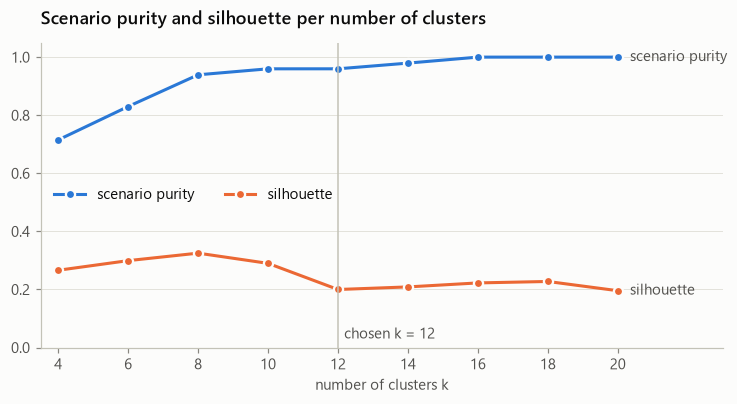

k,4,6,8,10,12,14,16,18,20
silhouette,0.266,0.299,0.325,0.29,0.20,0.209,0.222,0.227,0.196
scenario purity,0.715,0.830,0.939,0.96,0.96,0.979,1.000,1.000,1.000


In [12]:
K_RANGE = range(4, 21, 2)
sample = np.random.default_rng(SEED).choice(len(Z), size=min(5000, len(Z)), replace=False)

sweep = []
for k in K_RANGE:
    labels = KMeans(k, n_init=10, random_state=SEED).fit_predict(Z)
    purity = cl.groupby(labels)["Scenario"].agg(lambda s: s.value_counts().iloc[0]).sum() / len(cl)
    sweep.append({"k": k, "silhouette": silhouette_score(Z[sample], labels[sample]), "scenario purity": purity})
sweep = pd.DataFrame(sweep).set_index("k")

N_THEMES = 12  # every scenario gets a cluster; the big alert scenario splits by domain and resolution state

fig, ax = plt.subplots(figsize=(8, 3.6))
for col, color in [("scenario purity", ACCENT), ("silhouette", ACCENT_2)]:
    ax.plot(sweep.index, sweep[col], color=color, lw=2, marker="o", ms=6, mec=SURFACE, mew=1.5, label=col)
    ax.annotate(col, (sweep.index[-1], sweep[col].iloc[-1]), xytext=(8, 0), textcoords="offset points",
                va="center", color=INK_2)
ax.axvline(N_THEMES, color=AXIS, lw=1)
ax.annotate(f"chosen k = {N_THEMES}", (N_THEMES, 0.02), xytext=(4, 0), textcoords="offset points",
            va="bottom", color=INK_2)
ax.set(ylim=(0, 1.05), xlabel="number of clusters k", xticks=list(K_RANGE))
ax.set_title("Scenario purity and silhouette per number of clusters")
ax.grid(axis="y")
ax.legend(loc="center left", ncols=2)
ax.set_xlim(K_RANGE.start - 0.5, K_RANGE[-1] + 3)
plt.show()
sweep.round(3).T

### 4 · Themes

Each cluster is named from its data:
- the dominant **scenario**
- the **teams** that together cover most of its tickets
- a numeric **trait** (e.g. unresolved, few comments) if the cluster stands out on one

In [13]:
kmeans = KMeans(N_THEMES, n_init=10, random_state=SEED).fit(Z)
cl["Cluster"] = kmeans.labels_

TRAITS = {"unresolved": ("", "unresolved"), "comment count": ("few comments", "many comments"),
          "log resolution hours": ("fast resolution", "slow resolution")}
numeric_z = pd.DataFrame(StandardScaler().fit_transform(numeric), columns=numeric.columns)
feature_names = text_vectorizer.get_feature_names_out()
global_terms = np.asarray(text_tfidf.mean(axis=0)).ravel()


def top_values(series, cover=0.6, limit=3):
    """Smallest set of leading values that covers `cover` of the rows (at most `limit`)."""
    shares = series.value_counts(normalize=True)
    picked = shares.index[: max(1, min(limit, int((shares.cumsum() < cover).sum()) + 1))]
    return list(picked) if shares[picked].sum() >= cover else []


def describe(cluster):
    rows = cl["Cluster"] == cluster
    g = cl[rows]
    scenario = " / ".join(top_values(g["Scenario"], cover=0.6, limit=2)) or "Mixed scenarios"
    teams = " · ".join(top_values(g["Team"]))
    if not teams:
        # No small set of teams covers the theme -> name the teams that are over-represented instead.
        # Baseline = overall team mix restricted to the teams that occur in the theme; otherwise every
        # non-Service-Desk team looks over-represented just because the Service Desk is absent.
        shares = g["Team"].value_counts(normalize=True)
        baseline = cl["Team"].value_counts(normalize=True)[shares.index]
        lift = shares / (baseline / baseline.sum())
        over = lift[lift >= 1.5].sort_values(ascending=False).index[:2]
        teams = "esp. " + ", ".join(over) if len(over) else "all teams"
    trait = next((TRAITS[c][z > 0] for c, z in numeric_z[rows.to_numpy()].mean().items()
                  if c in TRAITS and abs(z) >= 1.0 and TRAITS[c][z > 0]), "")
    term_lift = np.asarray(text_tfidf[rows.to_numpy()].mean(axis=0)).ravel() - global_terms
    return {
        "Cluster": cluster,
        "Theme": scenario + (f" ({trait})" if trait else ""),
        "Teams": teams,
        "Tickets": len(g),
        "Share": len(g) / len(cl),
        "Work type": " / ".join(top_values(g["Work type"], cover=0.9, limit=2)),
        "Top services": ", ".join(g["Service"].value_counts().index[:3]),
        "Unresolved": g["Resolution hours"].isna().mean(),
        "Median resolution h": g["Resolution hours"].median(),
        "Key terms": ", ".join(feature_names[np.argsort(term_lift)[::-1][:5]]),
    }


themes = pd.DataFrame([describe(c) for c in range(N_THEMES)]).sort_values("Tickets", ascending=False)
themes["Label"] = themes["Theme"] + "\n" + themes["Teams"]
cl["Theme"] = cl["Cluster"].map(themes.set_index("Cluster")["Theme"])
order = themes["Cluster"].tolist()  # largest first; every chart below uses this order
label_of = themes.set_index("Cluster")["Label"]


def wrap(label, width):
    return "\n".join(textwrap.fill(part, width) for part in label.split("\n"))


themes.drop(columns="Label").assign(
    Share=themes["Share"].map("{:.1%}".format),
    Unresolved=themes["Unresolved"].map("{:.0%}".format),
    **{"Median resolution h": themes["Median resolution h"].round()},
).set_index("Cluster")

,Theme,Teams,Tickets,Share,Work type,Top services,Unresolved,Median resolution h,Key terms
Cluster,,,,,,,,,
7,Automated alert triggered,esp. Tax & Reporting,3882,19.4%,Incident,"SimCorp Dimension, Outlook & Email, Trade Matc...",0%,258.0,"automated, alert, alert indicating, triggered,..."
5,External email warning received,Service Desk,2972,14.9%,Incident,Emailed Support Tickets,15%,257.0,"warning, email, warning regarding, triage conf..."
1,Automated alert triggered,Investment Operations · Enterprise Application...,2344,11.7%,Incident,"Trading Platform, Fund Pricing, Portfolio Acco...",0%,275.0,"automated, alert, alert indicating, triggered,..."
6,Operational issue reported,all teams,1490,7.4%,Incident,"NAV Calculation, Corporate Actions, Regulatory...",16%,262.0,"reported, behaviour clear, behaviour, service ..."
4,Unclear incident input,all teams,1485,7.4%,Incident,"Securities Settlement, CRM & Client Portal, Id...",14%,266.0,"incident, accidental misrouted, unrelated, unr..."
0,Incident mislabelled as service request,all teams,1428,7.1%,Incident,"Order Management, Cash Management, Trade Matching",15%,265.0,"service request, incident, request, underlying..."
2,External email warning received (few comments),Service Desk,1240,6.2%,Incident,Emailed Support Tickets,15%,264.0,"warning, email, warning regarding, triage conf..."
11,Access removal requested / General request wit...,all teams,1218,6.1%,Service Request,"Tax Reporting, SharePoint & File Storage, SimC...",16%,251.0,"request, service request, unclear aligned, unc..."
3,Email notification received,Service Desk,1211,6.1%,Service Request,Emailed Support Tickets,13%,259.0,"warning related, triage determine, content gen..."


### 5 · Theme sizes

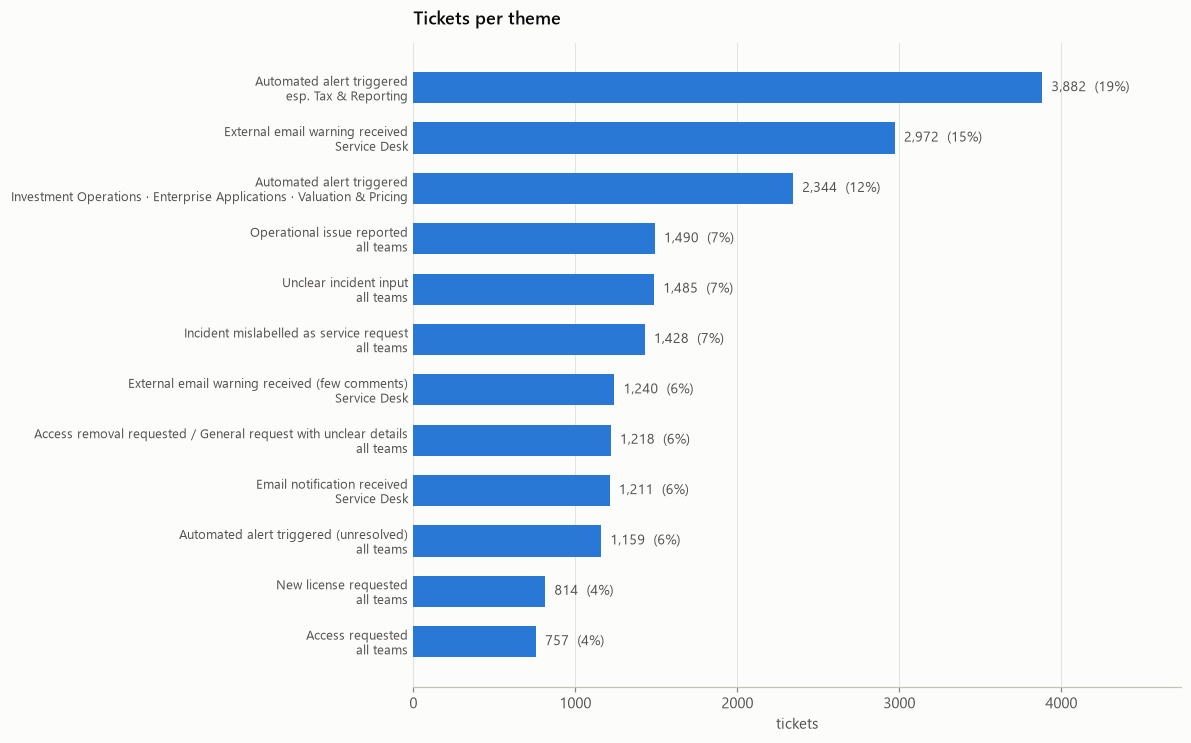

In [14]:
sizes = themes.set_index("Cluster")["Tickets"][order]
fig, ax = plt.subplots(figsize=(9, 0.55 * N_THEMES + 1))
y = np.arange(N_THEMES)
ax.barh(y, sizes.values, height=0.62, color=ACCENT)
for yi, value in zip(y, sizes.values):
    ax.annotate(f"{value:,}  ({value / len(cl):.0%})", (value, yi), xytext=(6, 0), textcoords="offset points",
                va="center", color=INK_2, fontsize=9)
ax.set_yticks(y, [label_of[c] for c in order], fontsize=8.5)
ax.invert_yaxis()
ax.set_xlim(0, sizes.max() * 1.22)
ax.grid(axis="x")
ax.set_axisbelow(True)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.set_xlabel("tickets")
ax.set_title("Tickets per theme")
plt.show()

### 6 · Map of the themes (t-SNE)

A 2-D t-SNE projection of a sample. With 12 themes, colour alone can't tell them apart, so each panel highlights one theme against all the others in grey. Distances *between* islands are not meaningful in t-SNE, only which points lie together.

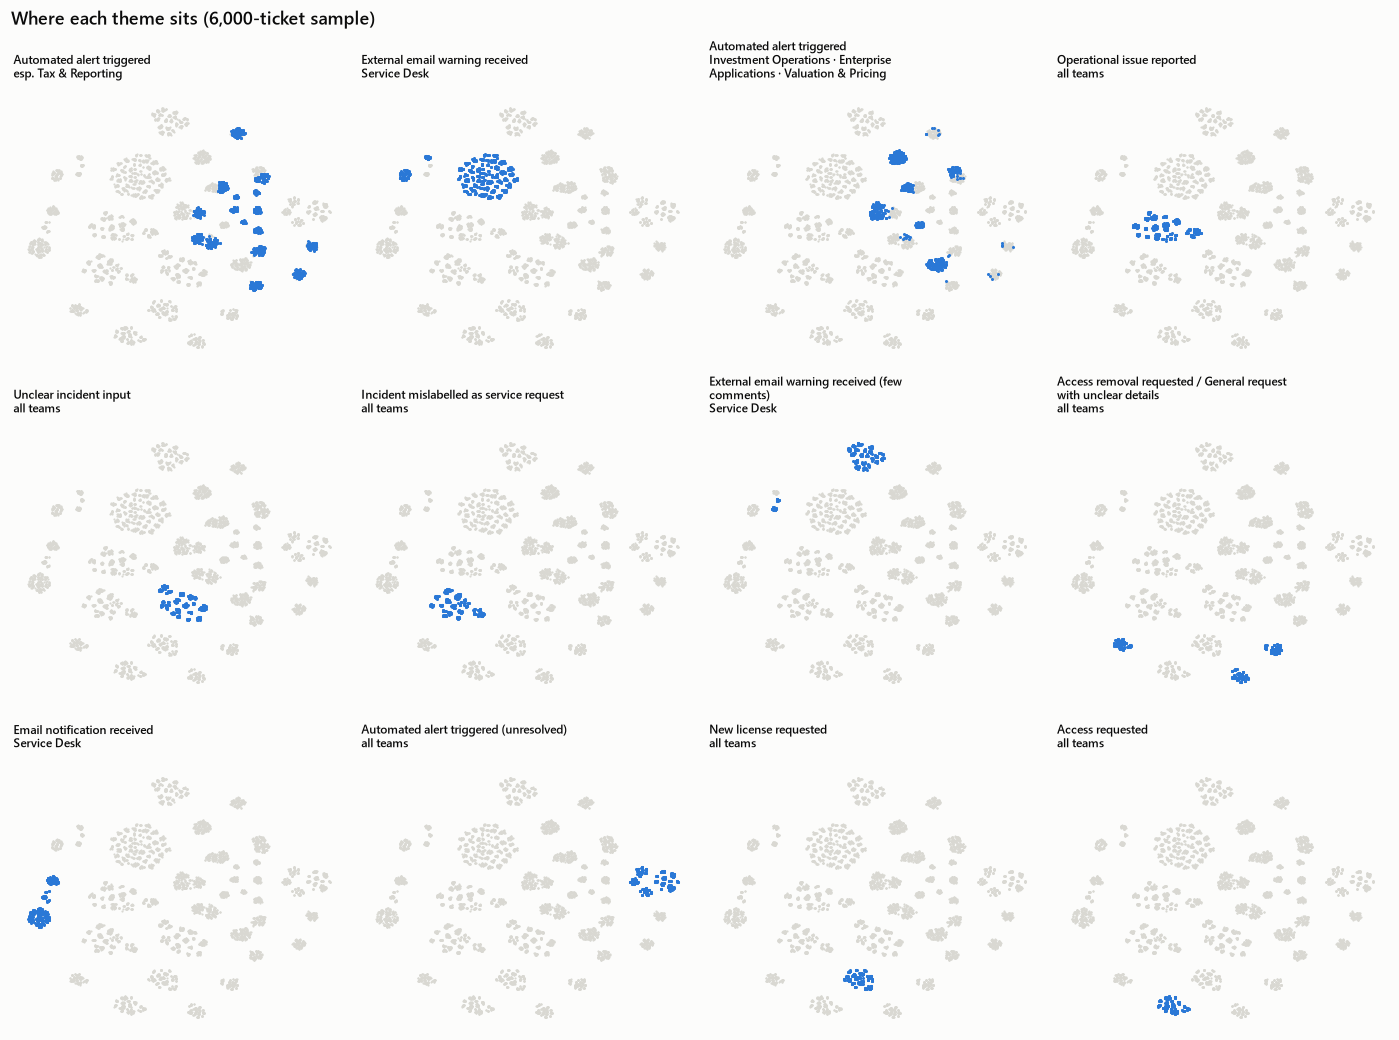

In [15]:
TSNE_SAMPLE = 6000
tsne_idx = np.random.default_rng(SEED).choice(len(Z), size=min(TSNE_SAMPLE, len(Z)), replace=False)
# The data is only 11 templates x 20 services, so thousands of tickets share a point;
# a little jitter keeps the density visible instead of stacking everything on single dots.
jitter = np.random.default_rng(SEED).normal(scale=0.02, size=(len(tsne_idx), Z.shape[1]))
xy = TSNE(n_components=2, perplexity=40, init="pca", random_state=SEED).fit_transform(Z[tsne_idx] + jitter)
sample_clusters = cl["Cluster"].to_numpy()[tsne_idx]

cols = 4
rows = int(np.ceil(N_THEMES / cols))
fig, axes = plt.subplots(rows, cols, figsize=(3.2 * cols, 3.2 * rows), sharex=True, sharey=True)
for ax, cluster in zip(axes.flat, order):
    mine = sample_clusters == cluster
    ax.scatter(*xy[~mine].T, s=2, color=CONTEXT, linewidths=0, rasterized=True)
    ax.scatter(*xy[mine].T, s=4, color=ACCENT, linewidths=0, rasterized=True)
    ax.set_title(wrap(label_of[cluster], 44), fontsize=8, loc="left", color=INK)
    ax.set_xticks([]), ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
for ax in axes.flat[N_THEMES:]:
    ax.set_visible(False)
fig.suptitle(f"Where each theme sits ({len(tsne_idx):,}-ticket sample)", x=0.01, ha="left",
             fontsize=12, fontweight="semibold")
fig.tight_layout()
plt.show()

### 7 · Which fields define a theme?

For every theme and field, the heatmap shows how much more **concentrated** the field is inside the theme than across all tickets: `1 − entropy(theme) / entropy(all tickets)`.
- **1 (dark):** the field has a single value in the theme, e.g. every ticket has the same work type.
- **0 (light):** the field is spread the same way as in the whole dataset, so it says nothing about the theme.

Priority, Urgency and Impact stay near 0 everywhere, as you would expect for random fields.

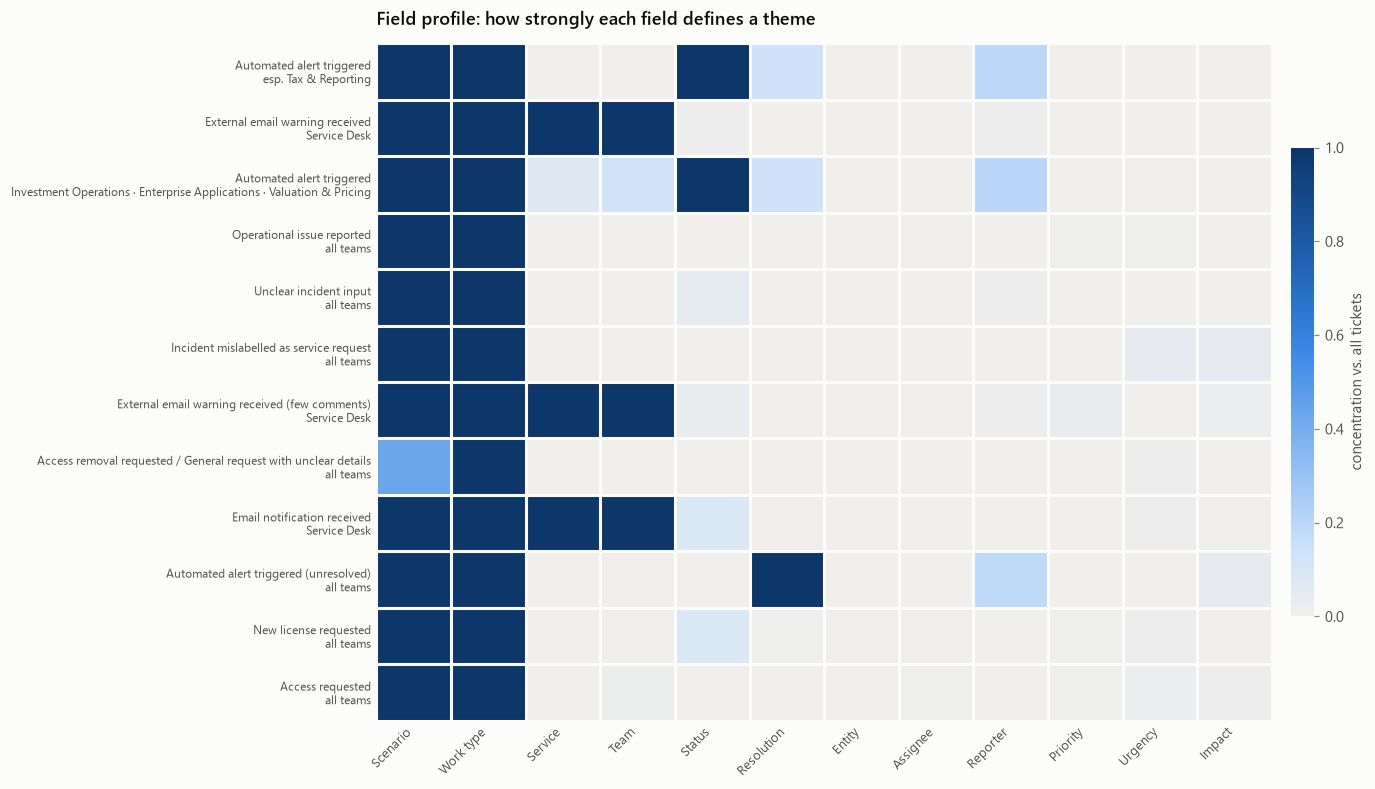

,Scenario,Work type,Service,Team,Status,Resolution,Entity,Assignee,Reporter,Priority,Urgency,Impact
Cluster,,,,,,,,,,,,
7,1.00,1.0,0.00,0.00,1.00,0.13,0.0,0.00,0.19,0.00,0.00,0.00
5,1.00,1.0,1.00,1.00,0.01,0.00,0.0,0.00,0.01,0.00,0.00,0.00
1,1.00,1.0,0.08,0.13,1.00,0.13,0.0,0.00,0.20,0.00,0.00,0.00
6,1.00,1.0,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.01,0.01,0.00
4,1.00,1.0,0.00,0.00,0.04,0.00,0.0,0.00,0.01,0.00,0.00,0.00
0,1.00,1.0,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.04,0.04
2,1.00,1.0,1.00,1.00,0.03,0.00,0.0,0.01,0.01,0.03,0.00,0.02
11,0.43,1.0,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.01,0.00
3,1.00,1.0,1.00,1.00,0.09,0.01,0.0,0.00,0.00,0.00,0.01,0.01


In [16]:
PROFILE_FIELDS = ["Scenario", "Work type", "Service", "Team", "Status", "Resolution",
                  "Entity", "Assignee", "Reporter", "Priority", "Urgency", "Impact"]


def entropy(series):
    p = series.value_counts(normalize=True).to_numpy()
    return -(p * np.log(p)).sum()


profile = pd.DataFrame({
    f: (1 - cl.groupby("Cluster")[f].agg(entropy) / entropy(cl[f])).clip(lower=0) for f in PROFILE_FIELDS
}).loc[order]


def heatmap(matrix, title, xlabels, cbar_label, figsize, rotate=45):
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(matrix.values, cmap=BLUES, vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(xlabels)), xlabels, rotation=rotate, ha="right" if rotate else "center", fontsize=8.5)
    ax.set_yticks(range(len(matrix)), [label_of[c] for c in matrix.index], fontsize=8)
    ax.set_xticks(np.arange(-0.5, matrix.shape[1]), minor=True)
    ax.set_yticks(np.arange(-0.5, matrix.shape[0]), minor=True)
    ax.grid(which="minor", color=SURFACE, lw=2)  # surface gap between cells instead of borders
    ax.tick_params(which="both", length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
    bar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    bar.outline.set_visible(False)
    bar.set_label(cbar_label, color=INK_2)
    ax.set_title(title)
    plt.show()


heatmap(profile, "Field profile: how strongly each field defines a theme", profile.columns,
        "concentration vs. all tickets", figsize=(11, 0.5 * N_THEMES + 2))
profile.round(2)

### 8 · Routing view: theme × team and theme × service

Column-normalised: each column shows which themes the tickets of one team or service fall into, and each column sums to 1. The darker a cell, the more typical that theme is for the team or service. Columns are sorted by ticket count.

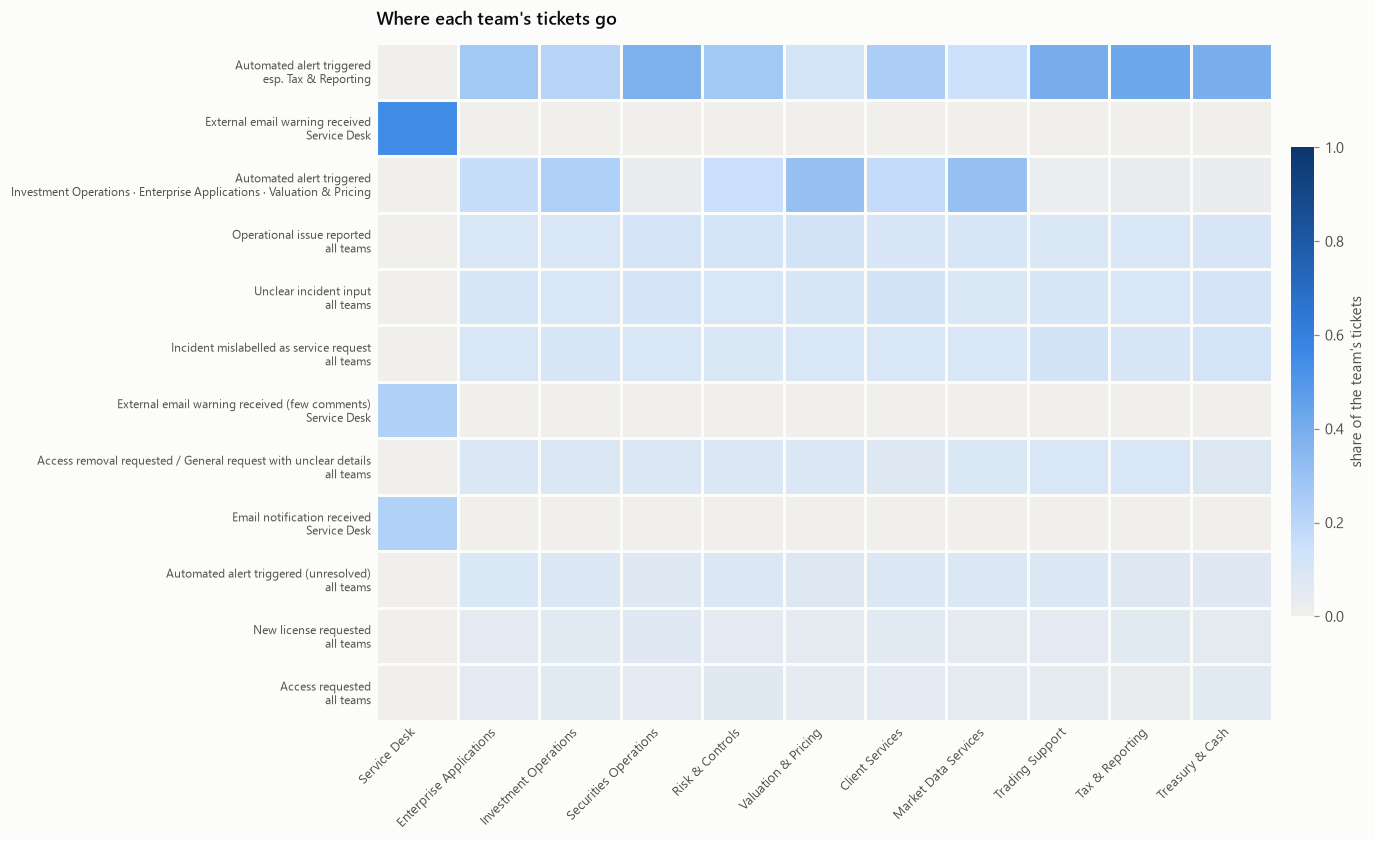

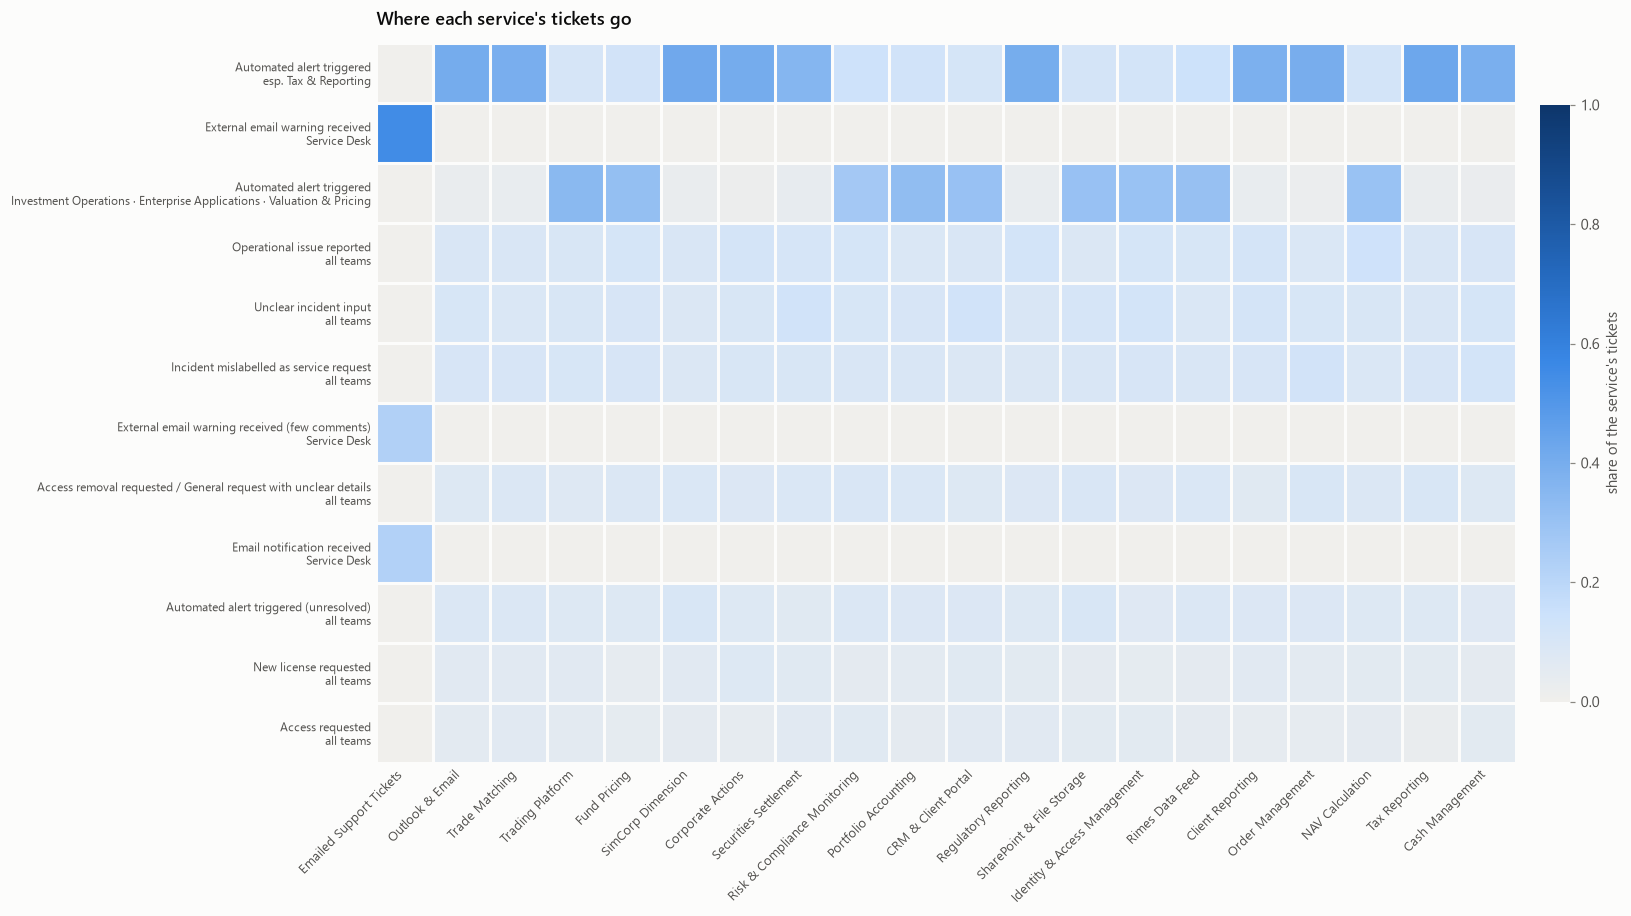

In [17]:
team_mix = pd.crosstab(cl["Cluster"], cl["Team"], normalize="columns").loc[order]
team_mix = team_mix[cl["Team"].value_counts().index]
heatmap(team_mix, "Where each team's tickets go", team_mix.columns, "share of the team's tickets",
        figsize=(11, 0.5 * N_THEMES + 2))

service_mix = pd.crosstab(cl["Cluster"], cl["Service"], normalize="columns").loc[order]
service_mix = service_mix[cl["Service"].value_counts().index]
heatmap(service_mix, "Where each service's tickets go", service_mix.columns, "share of the service's tickets",
        figsize=(14, 0.5 * N_THEMES + 2.5))

### 9 · Resolution time per theme

Only resolved tickets (the *Unresolved* column in the theme table has the rest). The box shows the middle 50 %, the line the median, and the whiskers the 5th–95th percentile.

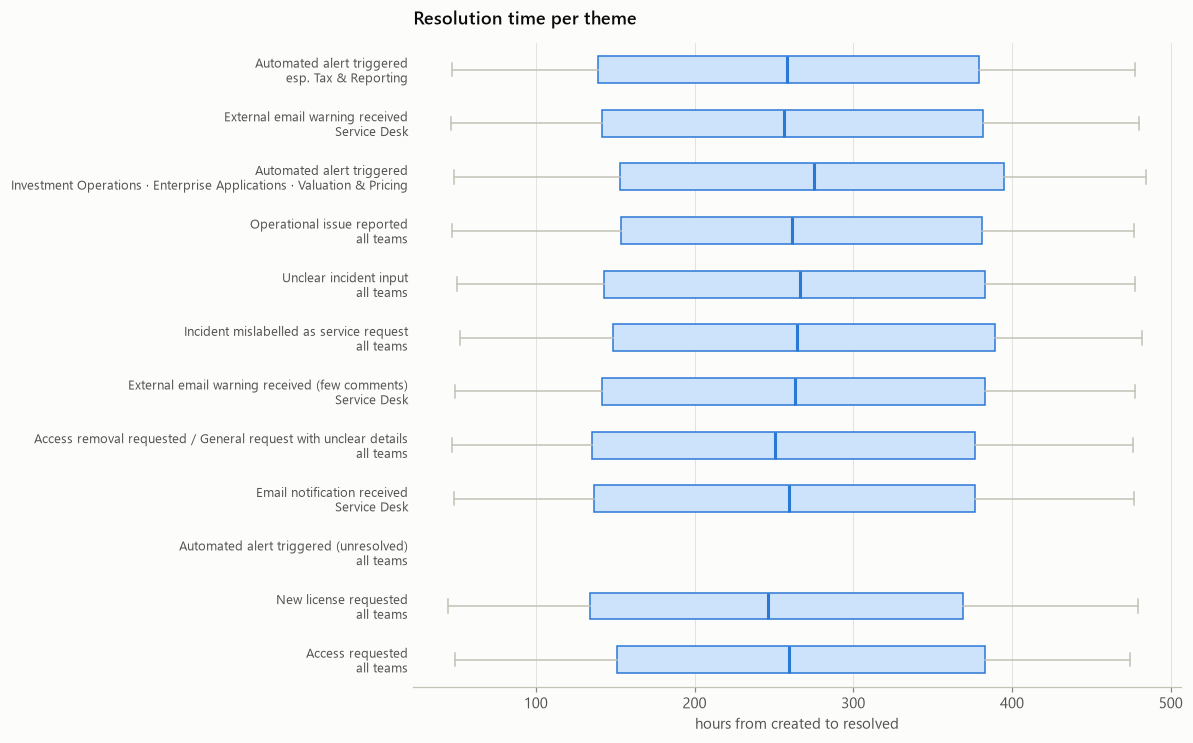

In [18]:
resolved = cl.dropna(subset=["Resolution hours"])
data = [resolved.loc[resolved["Cluster"] == c, "Resolution hours"].to_numpy() for c in order]

fig, ax = plt.subplots(figsize=(9, 0.55 * N_THEMES + 1))
# matplotlib 3.10 replaced vert=False with orientation="horizontal"
horizontal = {"orientation": "horizontal"} if tuple(map(int, matplotlib.__version__.split(".")[:2])) >= (3, 10) else {"vert": False}
ax.boxplot(data, **horizontal, whis=(5, 95), showfliers=False, widths=0.5, patch_artist=True,
                 medianprops={"color": ACCENT, "lw": 2},
                 boxprops={"facecolor": "#cde2fb", "edgecolor": ACCENT, "lw": 1},
                 whiskerprops={"color": AXIS, "lw": 1}, capprops={"color": AXIS, "lw": 1})
ax.set_yticks(range(1, N_THEMES + 1), [label_of[c] for c in order], fontsize=8.5)
ax.invert_yaxis()
ax.grid(axis="x")
ax.set_axisbelow(True)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.set_xlabel("hours from created to resolved")
ax.set_title("Resolution time per theme")
plt.show()

### 10 · Result

`cl[["Cluster", "Theme"]]` lines up with `df` by index. Join it to use the themes elsewhere:

```python
df.join(cl[["Cluster", "Theme"]])
```

In [19]:
df_themes = df.join(cl[["Cluster", "Theme"]])
df_themes[["Summary", "Affected Business or IT Services", "Service Team(s)", "Work type", "Theme"]].sample(10, random_state=SEED)

,Summary,Affected Business or IT Services,Service Team(s),Work type,Theme
10650,Automated alert triggered for Regulatory Repor...,[Regulatory Reporting],[Risk & Controls],Incident,Automated alert triggered
2041,General request for SharePoint & File Storage ...,[SharePoint & File Storage],[Enterprise Applications],Service Request,Access removal requested / General request wit...
8668,Operational issue reported for Trading Platform,[Trading Platform],[Investment Operations],Incident,Operational issue reported
1114,Email notification received for Emailed Suppor...,[Emailed Support Tickets],[Service Desk],Service Request,Email notification received
13902,Unclear incident input for SharePoint & File S...,[SharePoint & File Storage],[Enterprise Applications],Incident,Unclear incident input
11963,Automated alert triggered for Trading Platform,[Trading Platform],[Investment Operations],Incident,Automated alert triggered
11072,Automated alert triggered for Client Reporting,[Client Reporting],[Client Services],Incident,Automated alert triggered
3002,Incorrect incident title for service request i...,[Tax Reporting],[Tax & Reporting],Service Request,Access removal requested / General request wit...
19771,Unclear incident input for Cash Management,[Cash Management],[Treasury & Cash],Incident,Unclear incident input
8115,Automated alert triggered for Tax Reporting,[Tax Reporting],[Tax & Reporting],Incident,Automated alert triggered
